# K-Means en Iris

Objetivo: agrupar observaciones, elegir k con criterios simples y comparar contra la etiqueta real.

## 1) Librerias

In [1]:
!pip install pandas matplotlib seaborn scikit-learn

In [2]:
# Datos
import pandas as pd


In [3]:
# Calculo numerico
import numpy as np


In [4]:
# Graficos
import matplotlib.pyplot as plt


In [5]:
# Graficos estadisticos
import seaborn as sns


In [6]:
# Clustering
from sklearn.cluster import KMeans


In [7]:
# Escalamiento
from sklearn.preprocessing import StandardScaler


In [8]:
# Metricas de cluster
from sklearn.metrics import silhouette_score


In [9]:
# Estilo visual
sns.set_theme(style="whitegrid")


## 2) Cargar y explorar datos

In [10]:
# Cargar archivo
iris_data = pd.read_csv("iris.csv")


In [11]:
# Convertir variedad a categoria
iris_data["variety"] = iris_data["variety"].astype("category")


In [12]:
# Vista rapida
iris_data.head()


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [13]:
# Resumen
iris_data.describe(include="all")


,sepal.length,sepal.width,petal.length,petal.width,variety
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,Setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.057333,3.758000,1.199333,NaN
std,0.828066,0.435866,1.765298,0.762238,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


## 3) Preparar variables numericas y normalizar

In [14]:
# Quedarse con columnas numericas
iris_numerico = iris_data.select_dtypes(include=["number"])


In [15]:
# Estandarizar
scaler = StandardScaler()
iris_normalizado = scaler.fit_transform(iris_numerico)


## 4) Elegir numero de clusters

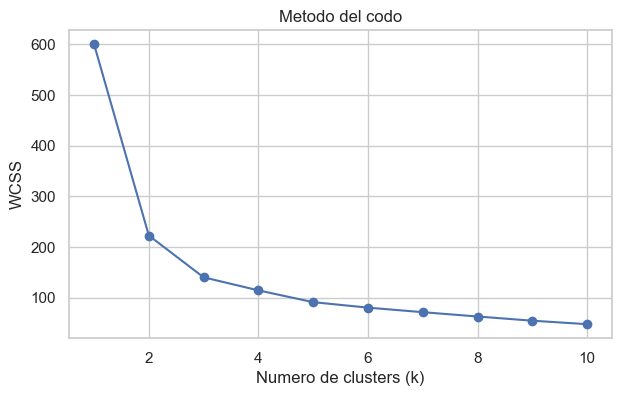

In [16]:
# Metodo del codo (WCSS)
k_values = list(range(1, 11))
wcss = []
for k in k_values:
    modelo_temp = KMeans(n_clusters=k, random_state=42, n_init=25)
    modelo_temp.fit(iris_normalizado)
    wcss.append(modelo_temp.inertia_)
plt.figure(figsize=(7, 4))
plt.plot(k_values, wcss, marker="o")
plt.title("Metodo del codo")
plt.xlabel("Numero de clusters (k)")
plt.ylabel("WCSS")
plt.show()


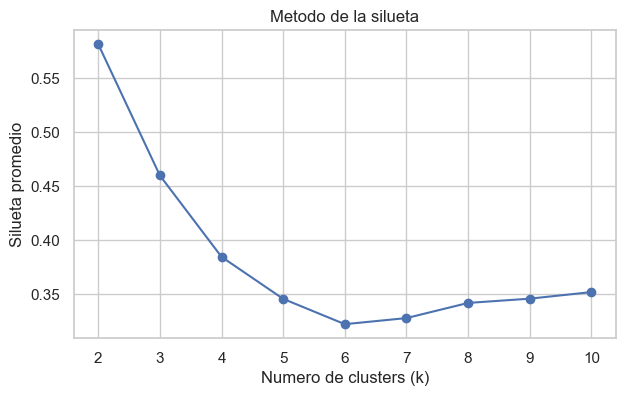

In [17]:
# Metodo de silueta
k_values_sil = list(range(2, 11))
sil_scores = []
for k in k_values_sil:
    modelo_temp = KMeans(n_clusters=k, random_state=42, n_init=25)
    labels_temp = modelo_temp.fit_predict(iris_normalizado)
    score_temp = silhouette_score(iris_normalizado, labels_temp)
    sil_scores.append(score_temp)
plt.figure(figsize=(7, 4))
plt.plot(k_values_sil, sil_scores, marker="o")
plt.title("Metodo de la silueta")
plt.xlabel("Numero de clusters (k)")
plt.ylabel("Silueta promedio")
plt.show()


## 5) Entrenar K-Means con k = 3

In [18]:
# Crear modelo final
kmeans_result = KMeans(n_clusters=3, random_state=42, n_init=25, max_iter=100)


In [19]:
# Ajustar y obtener clusters
clusters = kmeans_result.fit_predict(iris_normalizado) + 1


In [20]:
# Centroides
pd.DataFrame(kmeans_result.cluster_centers_, columns=iris_numerico.columns, index=["Cluster_1", "Cluster_2", "Cluster_3"])


,sepal.length,sepal.width,petal.length,petal.width
Cluster_1,-0.050220,-0.883376,0.347738,0.281527
Cluster_2,-1.014579,0.853263,-1.304987,-1.254893
Cluster_3,1.135970,0.088422,0.996155,1.017526


In [21]:
# Tamano de cada cluster
pd.Series(clusters).value_counts().sort_index().rename("n")


1    53
2    50
3    47
Name: n, dtype: int64

In [22]:
# WCSS por cluster
pd.Series(kmeans_result.inertia_)


0    139.820496
dtype: float64

## 6) Visualizar clusters

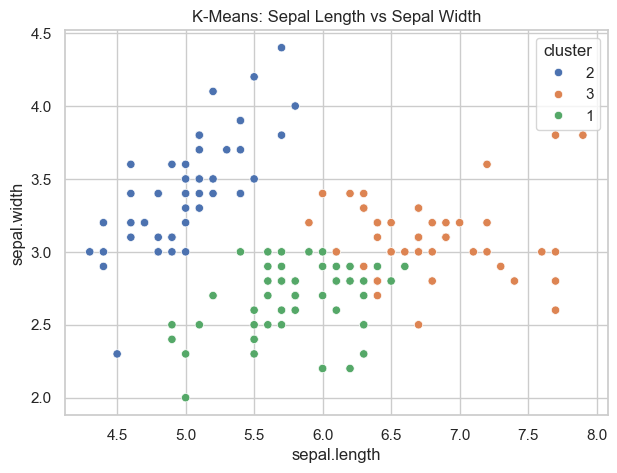

In [23]:
# Scatter 1: Sepal Length vs Sepal Width
iris_clusters = iris_data.copy()
iris_clusters["cluster"] = clusters.astype(str)
plt.figure(figsize=(7, 5))
sns.scatterplot(data=iris_clusters, x="sepal.length", y="sepal.width", hue="cluster")
plt.title("K-Means: Sepal Length vs Sepal Width")
plt.show()


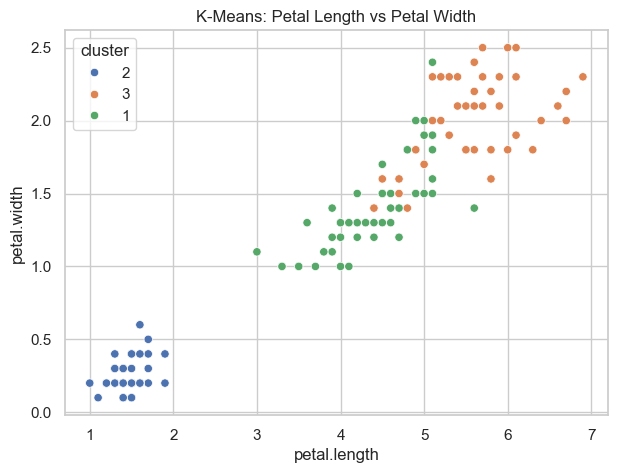

In [24]:
# Scatter 2: Petal Length vs Petal Width
plt.figure(figsize=(7, 5))
sns.scatterplot(data=iris_clusters, x="petal.length", y="petal.width", hue="cluster")
plt.title("K-Means: Petal Length vs Petal Width")
plt.show()


## 7) Comparar clusters con variedades reales

In [25]:
# Tabla de contingencia
tabla = pd.crosstab(iris_clusters["cluster"], iris_clusters["variety"])
tabla.index = [f"Cluster_{x}" for x in tabla.index]
tabla.columns = [f"Variety_{x}" for x in tabla.columns]
tabla


,Variety_Setosa,Variety_Versicolor,Variety_Virginica
Cluster_1,0,39,14
Cluster_2,50,0,0
Cluster_3,0,11,36


## 8) Probar diferentes valores de k (2 a 5)

In [26]:
# Comparacion simple de WCSS por k
comparacion_k = []
for k in [2, 3, 4, 5]:
    modelo_k = KMeans(n_clusters=k, random_state=42, n_init=25)
    modelo_k.fit(iris_normalizado)
    comparacion_k.append([k, modelo_k.inertia_])
pd.DataFrame(comparacion_k, columns=["k", "WCSS"])


,k,WCSS
0,2,222.361705
1,3,139.820496
2,4,114.092328
3,5,90.807592
